In [2]:
# Install required libraries
!pip install transformers
!pip install torch
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertForSequenceClassification,
 get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load and preprocess data
df = pd.read_csv('/content/urdusentiment.csv')

In [4]:
# Step 1: Display total rows and columns in the dataset
print("Total rows and columns in the dataset:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Total rows and columns in the dataset:
Rows: 10008, Columns: 5


In [5]:
print(df.to_string(max_rows=10))

                                                                                                                                         Urdu Text Data    1    2    3 Lables
0                                                               جہاں تک بہترین سوفٹویئر کی بات ہے تو بہترین سوفٹویئر وہ ہے جو آپ کو استعمال کرنا آتا ہو  pos  pos  pos    pos
1                       معذرت چاہتا ہوں میں کسی اور خیال میں تھا میں یہ دونوں سوفٹویئر استعمال کر چکا ہوں لیکن صرف انگلش کے لئے یہ اردو سپورٹ نہیں کرتے  neu  neu  neu    neu
2                                                                                    اردو کے لئے سب سے آسان مائکروسوفٹ پبلشر ہے اور شاید سب سے سستا بھی  pos  pos  pos    pos
3      \nپیشگی معذرت اسد بھائی  \nاگر آپ مائیکرو سافٹ ورڈ اور مائیکرو سافٹ پبلشر میں کارگردگی  سہولت ومشکل ہونے کے اعتبار سے فرق سمجھائے تو نوازش ہوگی   pos  pos  pos    pos
4                                                                                    عارف کریم بھائی  کرننگ کی وضاحت ہو تو مجھ جیس

In [6]:
# Step 2: Display total count of tweets before removing neutral tweets
print("\nTotal count of tweets before removing neutral tweets:")
print(df['Lables'].value_counts())


Total count of tweets before removing neutral tweets:
Lables
neu    3728
pos    3719
neg    2561
Name: count, dtype: int64


In [7]:
# Check for null values
print("\nChecking for null values:")
print(df.isnull().sum())


Checking for null values:
Urdu Text Data    0
1                 0
2                 2
3                 0
Lables            0
dtype: int64


In [8]:
# Remove null values
df = df.dropna()
print("\nNull values removed.")


Null values removed.


In [9]:
# Step 3: Filter out neutral tweets and convert to binary classification
df = df[df['Lables'] != 'neu']
df['label'] = df['Lables'].map({'pos': 1, 'neg': 0})

<ipython-input-9-bc34383775bf>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['Lables'].map({'pos': 1, 'neg': 0})


In [10]:
# Step 4: Display total count of tweets after removing neutral tweets
print("\nTotal count of tweets after removing neutral tweets:")
print(df['label'].value_counts())


Total count of tweets after removing neutral tweets:
label
1    3718
0    2561
Name: count, dtype: int64


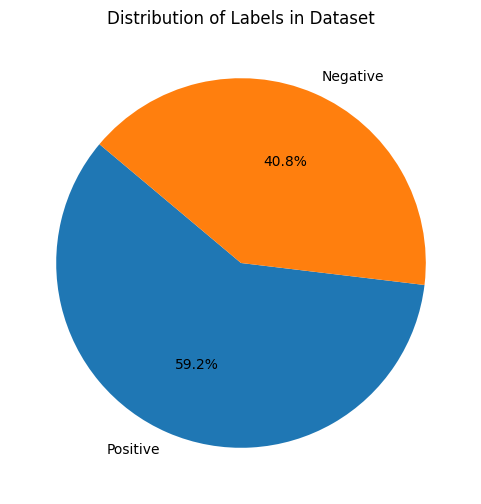

In [11]:
# Pie chart of dataset
label_counts = df['label'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=['Positive', 'Negative'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels in Dataset')
plt.show()

In [16]:
# Split into train and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Urdu Text Data'], df['label'], test_size=0.2, random_state=42
)

In [17]:
# Tokenization function
def tokenize(texts, tokenizer, max_length=128):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

In [18]:
# Dataset class
class UrduDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenize(texts, tokenizer)
        self.labels = torch.tensor(labels.tolist())

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

    def __len__(self):
        return len(self.labels)


In [19]:
# Load tokenizers for both models
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
multilingual_tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [20]:
# Create datasets for both models
bert_train_dataset = UrduDataset(train_texts, train_labels, bert_tokenizer)
bert_val_dataset = UrduDataset(val_texts, val_labels, bert_tokenizer)

multilingual_train_dataset = UrduDataset(train_texts, train_labels, multilingual_tokenizer)
multilingual_val_dataset = UrduDataset(val_texts, val_labels, multilingual_tokenizer)

In [21]:
# Model setup
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
multilingual_model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)
multilingual_model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [22]:
# Training parameters
BATCH_SIZE = 8
EPOCHS = 10
LEARNING_RATE = 2e-5

bert_train_loader = DataLoader(bert_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
bert_val_loader = DataLoader(bert_val_dataset, batch_size=BATCH_SIZE)

multilingual_train_loader = DataLoader(multilingual_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
multilingual_val_loader = DataLoader(multilingual_val_dataset, batch_size=BATCH_SIZE)


In [25]:
# Optimizer and scheduler for both models
from torch.optim import AdamW # Import AdamW from torch.optim

bert_optimizer = AdamW(bert_model.parameters(), lr=LEARNING_RATE)
multilingual_optimizer = AdamW(multilingual_model.parameters(), lr=LEARNING_RATE)

total_steps = len(bert_train_loader) * EPOCHS

bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

multilingual_scheduler = get_linear_schedule_with_warmup(
    multilingual_optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [27]:
import torch
from sklearn.metrics import accuracy_score

# Training loop for BERT model
bert_train_losses = []
bert_val_losses = []
bert_val_accuracies = []

for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0

    for batch in bert_train_loader:
        bert_optimizer.zero_grad()
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device),
            'labels': batch['labels'].to(device)
        }

        outputs = bert_model(**inputs)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        bert_optimizer.step()
        bert_scheduler.step()

    avg_train_loss = total_loss / len(bert_train_loader)
    bert_train_losses.append(avg_train_loss)
    print(f"BERT Epoch {epoch+1}/{EPOCHS}")
    print(f"Train loss: {avg_train_loss:.2f}")

    # Validation
    bert_model.eval()
    val_loss = 0
    val_predictions = []
    val_true_labels = []

    with torch.no_grad():  # No gradient calculation during validation
        for batch in bert_val_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['labels'].to(device)
            }
            outputs = bert_model(**inputs)
            loss = outputs.loss
            val_loss += loss.item()

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1).cpu().numpy()
            true_labels = batch['labels'].cpu().numpy()

            val_predictions.extend(predictions)
            val_true_labels.extend(true_labels)

    avg_val_loss = val_loss / len(bert_val_loader)
    bert_val_losses.append(avg_val_loss)
    val_accuracy = accuracy_score(val_true_labels, val_predictions)
    bert_val_accuracies.append(val_accuracy)

    print(f"Validation loss: {avg_val_loss:.2f}")
    print(f"Validation accuracy: {val_accuracy:.2f}")

BERT Epoch 1/10
Train loss: 0.50
Validation loss: 0.49
Validation accuracy: 0.75
BERT Epoch 2/10
Train loss: 0.44
Validation loss: 0.49
Validation accuracy: 0.78
BERT Epoch 3/10
Train loss: 0.39
Validation loss: 0.54
Validation accuracy: 0.80
BERT Epoch 4/10
Train loss: 0.34
Validation loss: 0.56
Validation accuracy: 0.80
BERT Epoch 5/10
Train loss: 0.30
Validation loss: 0.68
Validation accuracy: 0.80
BERT Epoch 6/10
Train loss: 0.28
Validation loss: 0.79
Validation accuracy: 0.80
BERT Epoch 7/10
Train loss: 0.23
Validation loss: 0.95
Validation accuracy: 0.79
BERT Epoch 8/10
Train loss: 0.20
Validation loss: 0.98
Validation accuracy: 0.80
BERT Epoch 9/10
Train loss: 0.17
Validation loss: 1.03
Validation accuracy: 0.79
BERT Epoch 10/10
Train loss: 0.18
Validation loss: 1.03
Validation accuracy: 0.79


In [28]:
# Training loop for Multilingual BERT model
multilingual_train_losses = []
for epoch in range(EPOCHS):
    multilingual_model.train()
    total_loss = 0

    for batch in multilingual_train_loader:
        multilingual_optimizer.zero_grad()
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device),
            'labels': batch['labels'].to(device)
        }

        outputs = multilingual_model(**inputs)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(multilingual_model.parameters(), 1.0)
        multilingual_optimizer.step()
        multilingual_scheduler.step()

    avg_train_loss = total_loss / len(multilingual_train_loader)
    multilingual_train_losses.append(avg_train_loss)
    print(f"Multilingual BERT Epoch {epoch+1}/{EPOCHS}")
    print(f"Train loss: {avg_train_loss:.2f}")


Multilingual BERT Epoch 1/10
Train loss: 0.49
Multilingual BERT Epoch 2/10
Train loss: 0.35
Multilingual BERT Epoch 3/10
Train loss: 0.31
Multilingual BERT Epoch 4/10
Train loss: 0.21
Multilingual BERT Epoch 5/10
Train loss: 0.17
Multilingual BERT Epoch 6/10
Train loss: 0.14
Multilingual BERT Epoch 7/10
Train loss: 0.11
Multilingual BERT Epoch 8/10
Train loss: 0.08
Multilingual BERT Epoch 9/10
Train loss: 0.03
Multilingual BERT Epoch 10/10
Train loss: 0.03


In [29]:
# Evaluation with Additional Metrics for both models
def evaluate_model(model, val_loader):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['labels'].to(device)
            }

            outputs = model(**inputs)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(inputs['labels'].cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)
    conf_matrix = confusion_matrix(true_labels, predictions)

    return accuracy, precision, recall, f1, conf_matrix

bert_accuracy, bert_precision, bert_recall, bert_f1, bert_conf_matrix = evaluate_model(bert_model, bert_val_loader)
multilingual_accuracy, multilingual_precision, multilingual_recall, multilingual_f1, multilingual_conf_matrix = evaluate_model(multilingual_model, multilingual_val_loader)

In [30]:
# Print Metrics for BERT model
print("BERT Model Metrics:")
print(f"Accuracy: {bert_accuracy:.4f}")
print(f"Precision: {bert_precision:.4f}")
print(f"Recall: {bert_recall:.4f}")
print(f"F1 Score: {bert_f1:.4f}")


BERT Model Metrics:
Accuracy: 0.7938
Precision: 0.8174
Recall: 0.8320
F1 Score: 0.8246


In [31]:
# Print Metrics for Multilingual BERT model
print("Multilingual BERT Model Metrics:")
print(f"Accuracy: {multilingual_accuracy:.4f}")
print(f"Precision: {multilingual_precision:.4f}")
print(f"Recall: {multilingual_recall:.4f}")
print(f"F1 Score: {multilingual_f1:.4f}")


Multilingual BERT Model Metrics:
Accuracy: 0.8639
Precision: 0.8755
Recall: 0.8934
F1 Score: 0.8844


In [32]:
# Violin plot for comparison
import seaborn as sns
import pandas as pd

# Create a DataFrame for the violin plot
data = {
    'Model': ['BERT'] * len(bert_train_losses) + ['Multilingual BERT'] * len(multilingual_train_losses),
    'Loss': bert_train_losses + multilingual_train_losses
}

df_violin = pd.DataFrame(data)

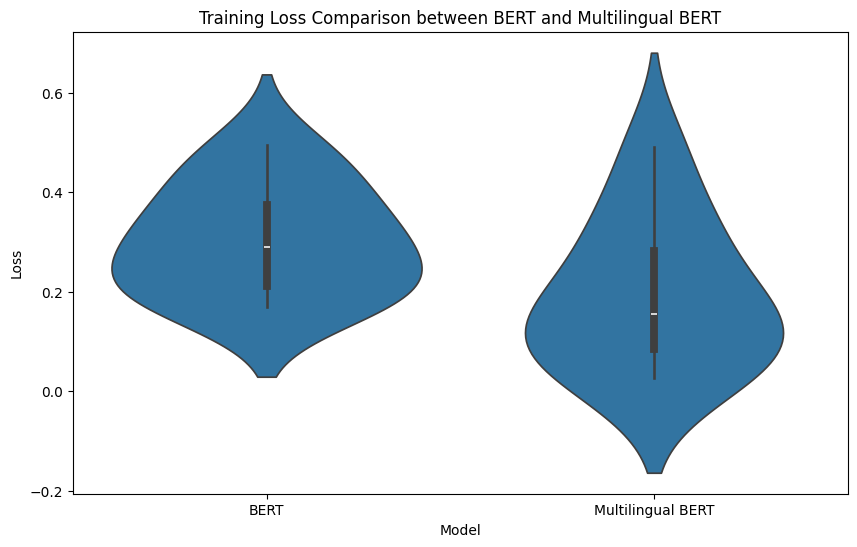

In [33]:
# Plot the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Model', y='Loss', data=df_violin)
plt.title('Training Loss Comparison between BERT and Multilingual BERT')
plt.show()

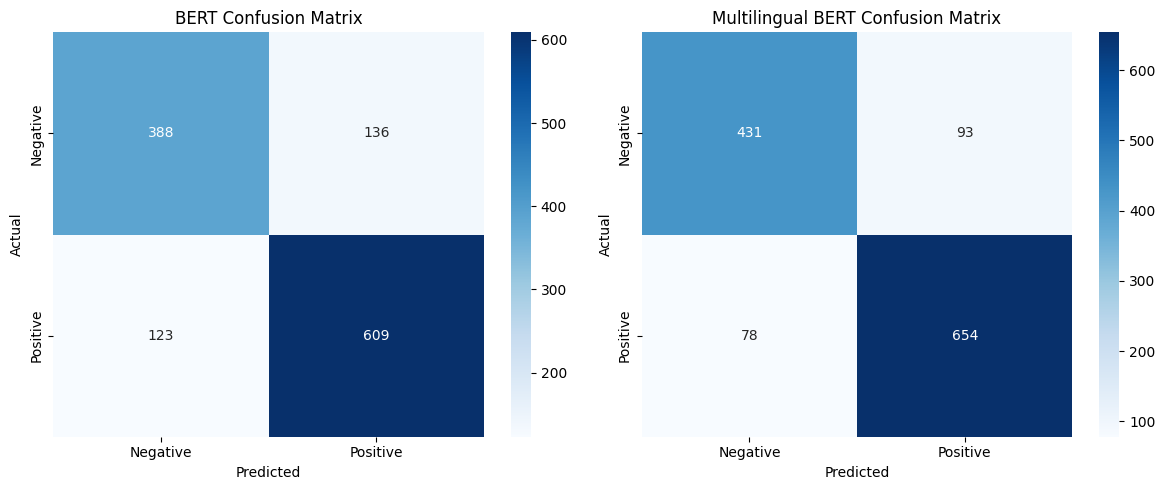

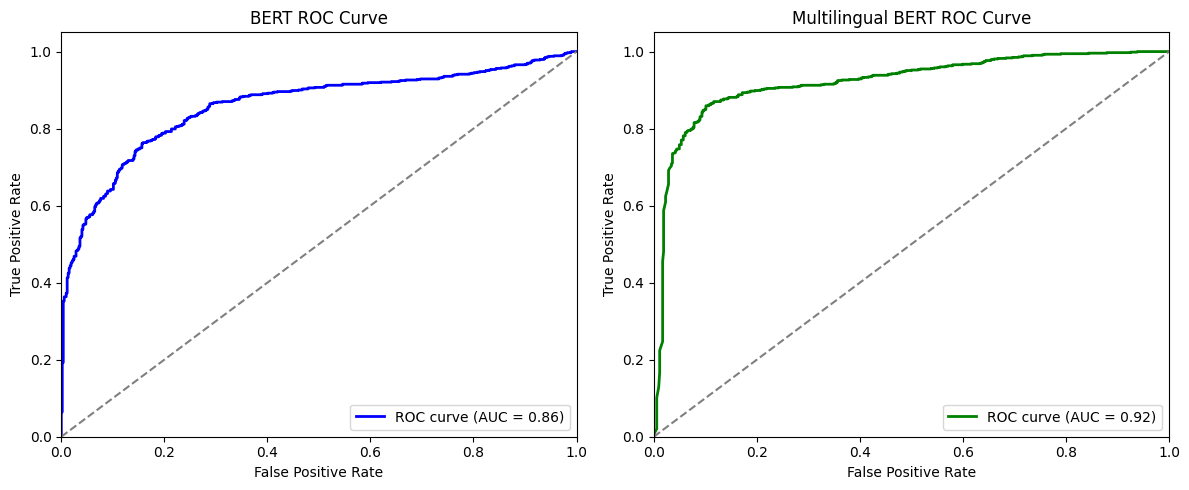


Model Performance Comparison:
Metric         BERT           Multilingual BERT
Accuracy       0.79380.8639
Precision      0.81740.8755
Recall         0.83200.8934
F1 Score       0.82460.8844


In [34]:
# Import necessary libraries for ROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to evaluate model and return probabilities for ROC curve
def evaluate_model_with_probs(model, val_loader):
    model.eval()
    predictions, true_labels, probabilities = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['labels'].to(device)
            }

            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(inputs['labels'].cpu().numpy())
            probabilities.extend(probs.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)
    conf_matrix = confusion_matrix(true_labels, predictions)

    # Get probabilities for the positive class
    probs_positive = np.array(probabilities)[:, 1]

    return accuracy, precision, recall, f1, conf_matrix, probs_positive, true_labels

# Evaluate both models with probabilities
bert_metrics = evaluate_model_with_probs(bert_model, bert_val_loader)
multilingual_metrics = evaluate_model_with_probs(multilingual_model, multilingual_val_loader)

# Unpack results
bert_accuracy, bert_precision, bert_recall, bert_f1, bert_conf_matrix, bert_probs, bert_true = bert_metrics
multilingual_accuracy, multilingual_precision, multilingual_recall, multilingual_f1, multilingual_conf_matrix, multilingual_probs, multilingual_true = multilingual_metrics

# Plot Confusion Matrices
plt.figure(figsize=(12, 5))

# BERT Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(bert_conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Confusion Matrix")

# Multilingual BERT Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(multilingual_conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multilingual BERT Confusion Matrix")

plt.tight_layout()
plt.show()

# Plot ROC Curves
plt.figure(figsize=(12, 5))

# BERT ROC Curve
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(bert_true, bert_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERT ROC Curve')
plt.legend(loc="lower right")

# Multilingual BERT ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(multilingual_true, multilingual_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multilingual BERT ROC Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Print metrics comparison
print("\nModel Performance Comparison:")
print(f"{'Metric':<15}{'BERT':<15}{'Multilingual BERT':<15}")
print(f"{'Accuracy':<15}{bert_accuracy:.4f}{multilingual_accuracy:.4f}")
print(f"{'Precision':<15}{bert_precision:.4f}{multilingual_precision:.4f}")
print(f"{'Recall':<15}{bert_recall:.4f}{multilingual_recall:.4f}")
print(f"{'F1 Score':<15}{bert_f1:.4f}{multilingual_f1:.4f}")

In [35]:
# Print metrics comparison with proper formatting
print("\nModel Performance Comparison:")
print(f"{'Metric':<15}{'BERT':<15}{'Multilingual BERT':<15}")
print(f"{'Accuracy':<15}{bert_accuracy:.4f}{'':<5}{multilingual_accuracy:.4f}")
print(f"{'Precision':<15}{bert_precision:.4f}{'':<5}{multilingual_precision:.4f}")
print(f"{'Recall':<15}{bert_recall:.4f}{'':<5}{multilingual_recall:.4f}")
print(f"{'F1 Score':<15}{bert_f1:.4f}{'':<5}{multilingual_f1:.4f}")


Model Performance Comparison:
Metric         BERT           Multilingual BERT
Accuracy       0.7938     0.8639
Precision      0.8174     0.8755
Recall         0.8320     0.8934
F1 Score       0.8246     0.8844
